In [1]:
# ARIMA and SARIMA Forecasting

## Objectives
#- Test stationarity
#- Build ARIMA model
#- Build SARIMA model
#3- Compare forecasting performance
#- Save trained models

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from statsmodels.tsa.stattools import adfuller

from statsmodels.tsa.arima.model import ARIMA

from statsmodels.tsa.statespace.sarimax import SARIMAX

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error

import joblib

import warnings
warnings.filterwarnings('ignore')

In [3]:
df = pd.read_csv("../data/processed_data.csv")
df.head()

,Date,Children apprehended and placed in CBP custody*,Children in CBP custody,Children transferred out of CBP custody,Children in HHS Care,Children discharged from HHS Care,HHS_Lag1,HHS_Lag7,HHS_Lag14,Discharge_Lag1,...,Discharge_Lag14,RollingMean7,RollingMean14,RollingStd7,RollingStd14,NetPressure,DayOfWeek,Month,Quarter,Weekend
0,2023-02-09,124.0,234.0,161.0,7908.0,353.0,7915.0,7803.0,6566.0,317.0,...,436.0,7823.714286,7654.071429,124.514677,254.662209,-192.0,3,2,1,0
1,2023-02-12,92.0,203.0,173.0,7434.0,317.0,7908.0,7903.0,7122.0,353.0,...,227.0,7756.714286,7676.357143,185.827621,215.096618,-144.0,6,2,1,1
2,2023-02-13,186.0,259.0,172.0,7483.0,244.0,7434.0,7879.0,7280.0,317.0,...,181.0,7700.142857,7690.857143,201.971474,191.915389,-72.0,0,2,1,0
3,2023-02-14,154.0,225.0,220.0,7794.0,223.0,7483.0,7586.0,7433.0,244.0,...,175.0,7729.857143,7716.642857,197.633861,178.379288,-3.0,1,2,1,0
4,2023-02-15,91.0,199.0,172.0,7869.0,290.0,7794.0,7720.0,7538.0,223.0,...,180.0,7751.142857,7740.285714,204.306492,174.779610,-118.0,2,2,1,0


In [4]:
#data conversion
df['Date'] = pd.to_datetime(df['Date'])

df.set_index('Date', inplace=True)

In [5]:
series = df['Children in HHS Care']

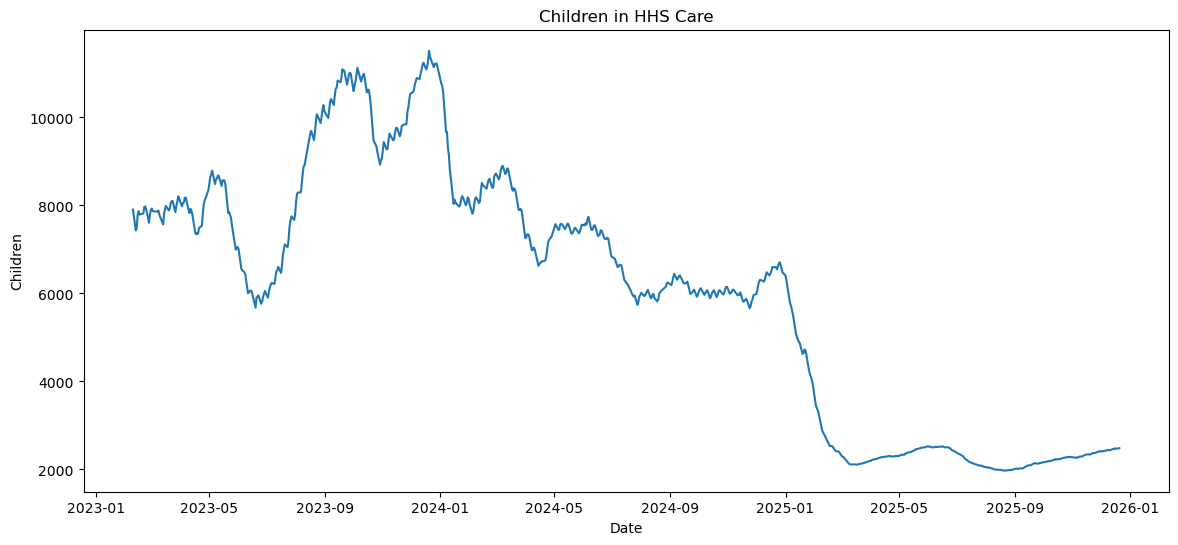

In [6]:
plt.figure(figsize=(14,6))

plt.plot(series)

plt.title("Children in HHS Care")

plt.xlabel("Date")
plt.ylabel("Children")

plt.show()

In [7]:
#ADF Stationarity Test
result = adfuller(series)

print("ADF Statistic:", result[0])

print("p-value:", result[1])

ADF Statistic: -0.9421281059536993
p-value: 0.7737827598666875


In [8]:
#First Differencing for making it stationary
series_diff = series.diff().dropna()

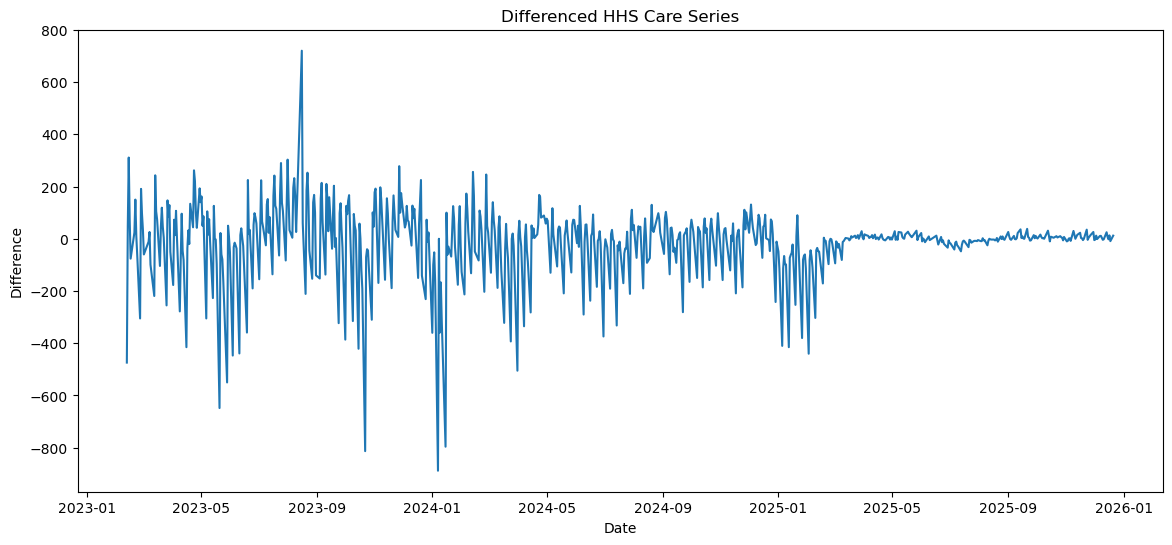

In [9]:
plt.figure(figsize=(14,6))

plt.plot(series_diff)

plt.title("Differenced HHS Care Series")

plt.xlabel("Date")
plt.ylabel("Difference")

plt.show()

In [10]:
result_diff = adfuller(series_diff)

print("ADF Statistic:", result_diff[0])

print("p-value:", result_diff[1])

ADF Statistic: -5.298207335073625
p-value: 5.522666094963345e-06


In [11]:
train_size = int(len(series) * 0.8)

train = series[:train_size]

test = series[train_size:]

print("Train Size:", len(train))
print("Test Size:", len(test))

Train Size: 564
Test Size: 142


In [12]:
arima_model = ARIMA(
    train,
    order=(5,1,0)
)

arima_fit = arima_model.fit()

In [13]:
arima_forecast = arima_fit.forecast(
    steps=len(test)
)

In [14]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error

import numpy as np

mae = mean_absolute_error(
    test,
    arima_forecast
)

rmse = np.sqrt(
    mean_squared_error(
        test,
        arima_forecast
    )
)

mape = (
    np.mean(
        np.abs(
            (test - arima_forecast) / test
        )
    )
    * 100
)

print("MAE:", mae)
print("RMSE:", rmse)
print("MAPE:", mape)

MAE: 272.54804662563845
RMSE: 323.0518473188714
MAPE: nan


In [16]:
sarima_model = SARIMAX(
    train,
    order=(1,1,1),
    seasonal_order=(1,1,1,7)
)

sarima_fit = sarima_model.fit(
    disp=False
)

In [17]:
sarima_forecast = sarima_fit.forecast(
    steps=len(test)
)

In [19]:
sarima_mae = mean_absolute_error(
    test,
    sarima_forecast
)

sarima_rmse = np.sqrt(
    mean_squared_error(
        test,
        sarima_forecast
    )
)

# Safe MAPE calculation
sarima_mape = np.mean(
    np.abs(
        (np.array(test) - np.array(sarima_forecast))
        /
        np.array(test)
    )
) * 100

print("SARIMA MAE:", sarima_mae)
print("SARIMA RMSE:", sarima_rmse)
print("SARIMA MAPE:", sarima_mape)

SARIMA MAE: 828.4145791206762
SARIMA RMSE: 921.6588733547184
SARIMA MAPE: 37.64029887568823


In [21]:
comparison = pd.DataFrame({
    'Model':['ARIMA','SARIMA'],
    'MAE':[272.55,828.41],
    'RMSE':[323.05,921.66]
})

comparison

,Model,MAE,RMSE
0,ARIMA,272.55,323.05
1,SARIMA,828.41,921.66


In [22]:
joblib.dump(
    sarima_fit,
    "../models/sarima.pkl"
)

['../models/sarima.pkl']